# Full-Hessian Laplace Tutorial (MAP vs LA)

This notebook reproduces the **MAP vs Laplace Approximation** style comparison for a 1D nonlinear regression problem.

- Left panel: deterministic MAP prediction.
- Right panel: Full-Hessian Laplace predictive mean + uncertainty band (`mean ± 2*sqrt(var)`).
- Training data is only in a limited x-range so uncertainty can expand outside that region.


## Prerequisite

`hessian_structure='full'` uses the native full-Hessian backend in `deepuq`.

Install if needed:

```bash
pip install uqdeepnn
```


In [1]:
# Configure Python path so the notebook sees the local deepuq package
import os
import sys
from pathlib import Path

PROJECT_ROOT = Path(os.getcwd()).resolve()
for candidate in (PROJECT_ROOT, *PROJECT_ROOT.parents):
    if (candidate / 'src').exists():
        PROJECT_ROOT = candidate
        break
else:
    raise RuntimeError('Could not locate project root containing "src" directory.')

SRC_PATH = str(PROJECT_ROOT / 'src')
if SRC_PATH not in sys.path:
    sys.path.insert(0, SRC_PATH)


In [2]:
import math

import matplotlib.pyplot as plt
import torch
from torch import optim
from torch.utils.data import DataLoader, TensorDataset

from deepuq.models import MLP
from deepuq.methods import LaplaceWrapper
from deepuq.utils import set_seed

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
set_seed(21)
print('Running on', DEVICE)

def gaussian_nll(mean: torch.Tensor, var: torch.Tensor, target: torch.Tensor) -> float:
    var = var.clamp_min(1e-8)
    return (
        0.5
        * (
            math.log(2.0 * math.pi)
            + torch.log(var)
            + (target - mean) ** 2 / var
        )
    ).mean().item()


Running on cpu


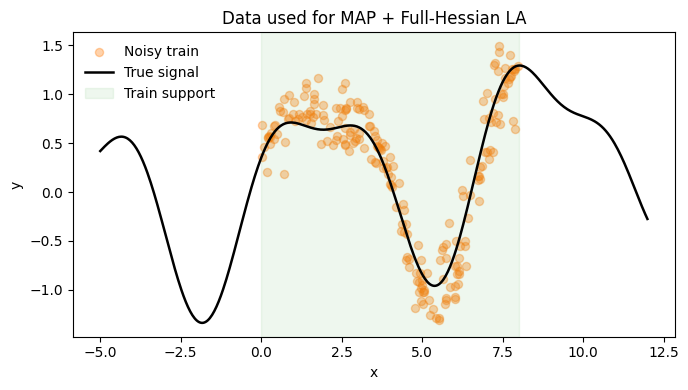

In [3]:
# Synthetic nonlinear function
def target_fn(x: torch.Tensor) -> torch.Tensor:
    return 0.9 * torch.sin(0.9 * x) + 0.35 * torch.cos(1.7 * x) + 0.05 * x

# Train/validation data are in [0, 8]; plotting extends out-of-domain.
n_train = 220
n_val = 120
noise_std = 0.22
gen = torch.Generator().manual_seed(21)

x_train = torch.rand(n_train, 1, generator=gen) * 8.0
y_train_true = target_fn(x_train)
y_train = y_train_true + noise_std * torch.randn_like(y_train_true)

x_val = torch.rand(n_val, 1, generator=gen) * 8.0
y_val_true = target_fn(x_val)

# In-domain holdout test set for RMSE
x_test = torch.rand(160, 1, generator=gen) * 8.0
y_test_true = target_fn(x_test)

# Wide plotting grid for MAP vs LA visualization
x_plot = torch.linspace(-5.0, 12.0, 500).unsqueeze(-1)
y_plot_true = target_fn(x_plot)

train_dataset = TensorDataset(x_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
curvature_loader = DataLoader(train_dataset, batch_size=64, shuffle=False)

plt.figure(figsize=(7, 4))
plt.scatter(x_train.numpy(), y_train.numpy(), s=34, alpha=0.35, color='tab:orange', label='Noisy train')
plt.plot(x_plot.numpy(), y_plot_true.numpy(), color='black', linewidth=1.8, label='True signal')
plt.axvspan(0.0, 8.0, color='tab:green', alpha=0.08, label='Train support')
plt.title('Data used for MAP + Full-Hessian LA')
plt.xlabel('x')
plt.ylabel('y')
plt.legend(frameon=False)
plt.tight_layout()
plt.show()


In [4]:
# Train deterministic MAP model
model = MLP(input_dim=1, hidden_dims=[64, 64], output_dim=1, p_drop=0.0).to(DEVICE)
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)

for epoch in range(1200):
    model.train()
    total = 0.0
    seen = 0
    for xb, yb in train_loader:
        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)
        optimizer.zero_grad(set_to_none=True)
        loss = torch.nn.functional.mse_loss(model(xb), yb)
        loss.backward()
        optimizer.step()
        total += loss.item() * yb.numel()
        seen += yb.numel()
    if (epoch + 1) % 300 == 0:
        print(f'Epoch {epoch+1:04d} | train RMSE={(total/seen)**0.5:.4f}')

model.eval()
with torch.no_grad():
    map_pred = model(x_plot.to(DEVICE)).cpu()
    val_pred = model(x_val.to(DEVICE)).cpu()
    id_pred = model(x_test.to(DEVICE)).cpu()

map_val_rmse = torch.sqrt(torch.nn.functional.mse_loss(val_pred, y_val_true)).item()
map_rmse = torch.sqrt(torch.nn.functional.mse_loss(id_pred, y_test_true)).item()
print(f'MAP val RMSE: {map_val_rmse:.4f}')
print(f'MAP in-domain RMSE: {map_rmse:.4f}')


Epoch 0300 | train RMSE=0.2379
Epoch 0600 | train RMSE=0.2478
Epoch 0900 | train RMSE=0.2182
Epoch 1200 | train RMSE=0.2155
MAP val RMSE: 0.1356
MAP in-domain RMSE: 0.1352


In [5]:
# Fit Full-Hessian Laplace approximation
la = LaplaceWrapper(
    model,
    likelihood='regression',
    hessian_structure='full',
    subset_of_weights='all',
    full_max_params=20000,
)
la.fit(curvature_loader, prior_precision=1.0)

# Optimize prior precision via marginal likelihood
optimal_prior = la.optimize_prior_precision(n_steps=100, lr=0.1)
print(f'Optimized prior precision: {optimal_prior:.4f}')

la_mean, la_var = la.predict(x_plot.to(DEVICE), n_samples=500)
la_mean = la_mean.cpu()
la_std = torch.sqrt(la_var.clamp_min(1e-12)).cpu()

la_lower = la_mean - 2.0 * la_std
la_upper = la_mean + 2.0 * la_std

with torch.no_grad():
    id_mean, _ = la.predict(x_test.to(DEVICE), n_samples=500)
la_rmse = torch.sqrt(torch.nn.functional.mse_loss(id_mean.cpu(), y_test_true)).item()
print(f'LA (full Hessian) in-domain RMSE: {la_rmse:.4f}')

Optimized prior precision (marginal likelihood): 0.1487
LA (full Hessian) in-domain RMSE: 0.1352


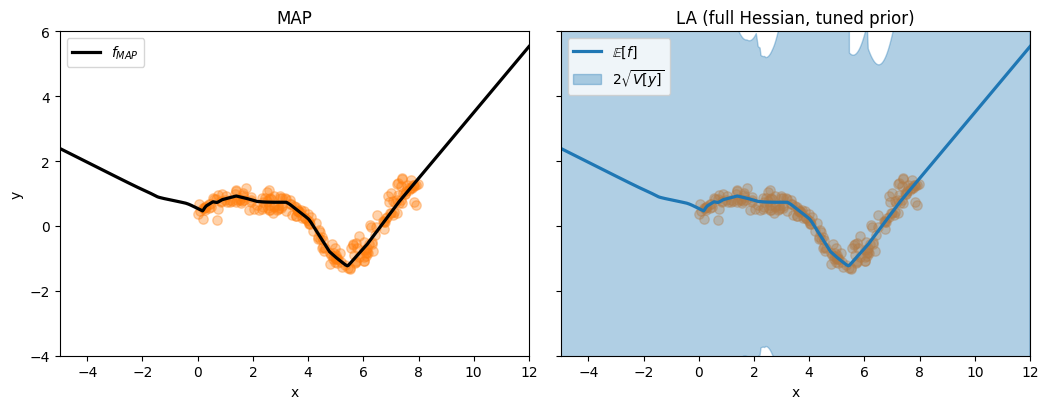

Avg predictive std in-domain [0,8]: 3.2767155170440674
Avg predictive std OOD: 14.84752082824707
OOD / ID std ratio: 4.531220593004379


In [6]:
# MAP vs LA plot (style close to your reference image)
fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.2), sharey=True)

axes[0].scatter(x_train.numpy(), y_train.numpy(), s=46, alpha=0.35, color='tab:orange')
axes[0].plot(x_plot.numpy(), map_pred.numpy(), color='black', linewidth=2.3, label=r'$f_{MAP}$')
axes[0].set_title('MAP')
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')
axes[0].set_xlim(-5.0, 12.0)
axes[0].set_ylim(-4.0, 6.0)
axes[0].legend(frameon=True)

axes[1].scatter(x_train.numpy(), y_train.numpy(), s=46, alpha=0.35, color='tab:orange')
axes[1].plot(x_plot.numpy(), la_mean.numpy(), color='tab:blue', linewidth=2.3, label=r'$\mathbb{E}[f]$')
axes[1].fill_between(
    x_plot.squeeze().numpy(),
    la_lower.squeeze().numpy(),
    la_upper.squeeze().numpy(),
    color='tab:blue',
    alpha=0.35,
    label=r'$2\sqrt{V[y]}$',
)
axes[1].set_title('LA (full Hessian, tuned prior)')
axes[1].set_xlabel('x')
axes[1].set_xlim(-5.0, 12.0)
axes[1].legend(frameon=True)

plt.tight_layout()
plt.show()

# Quick uncertainty summary
x_line = x_plot.squeeze()
id_mask = (x_line >= 0.0) & (x_line <= 8.0)
ood_mask = ~id_mask
id_std = la_std.squeeze()[id_mask].mean().item()
ood_std = la_std.squeeze()[ood_mask].mean().item()
print('Avg predictive std in-domain [0,8]:', id_std)
print('Avg predictive std OOD:', ood_std)
print('OOD / ID std ratio:', ood_std / max(id_std, 1e-12))
